In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import curve_fit

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.thorlabs import ThorCam

from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.holography import toolbox

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


In [2]:
cam = ThorCam()

TLCameraSDK initializing... success
Looking for cameras... success
ThorCam sn '38459' initializing... success


In [3]:
lut_path = "interpolated_voltage.lut"

slm = Meadowlark(lut_path=lut_path, wav_um=.688, settle_time_s=.3)

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...

In [4]:
fs = FourierSLM(cam, slm)

In [5]:
from slmsuite.holography.toolbox import convert_vector

origin_knm = convert_vector(
    [[0.0], [0.0]],
    from_units="kxy",
    to_units="knm",
    hardware=slm,
    shape=slm.shape,
)

pitch_point_knm = convert_vector(
    [[0.02], [0.00]],
    from_units="kxy",
    to_units="knm",
    hardware=slm,
    shape=slm.shape,
)

pitch_knm = pitch_point_knm - origin_knm;
print(pitch_point_knm, origin_knm, pitch_knm)

[[1406.51162791]
 [ 600.        ]] [[960.]
 [600.]] [[446.51162791]
 [  0.        ]]


In [6]:
slm.shape

(1200, 1920)

In [7]:
cam.set_exposure(0.001)

0.001013

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\toolbox\__init__.py:258: UserWarning: CameraSLM must be passed as slm for conversion 'kxy' to 'ij'
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

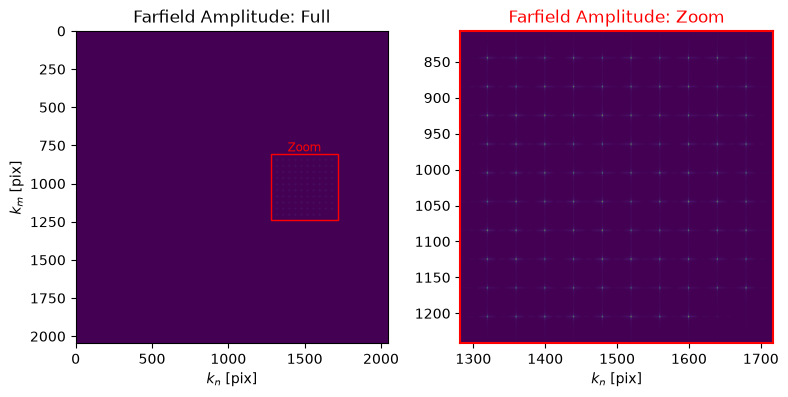

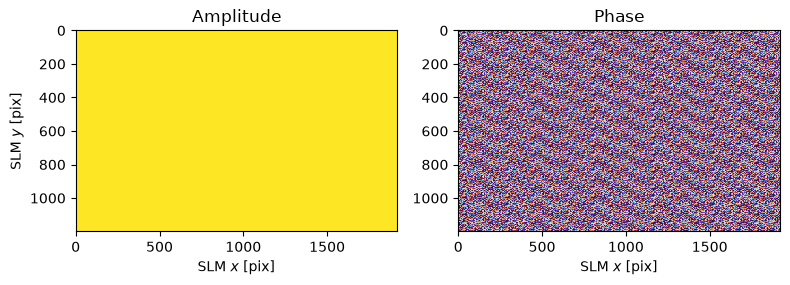

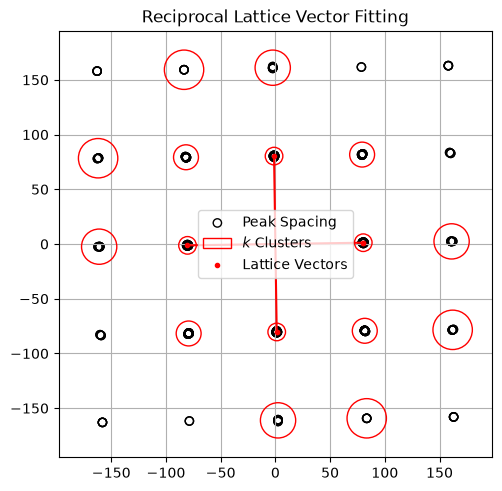

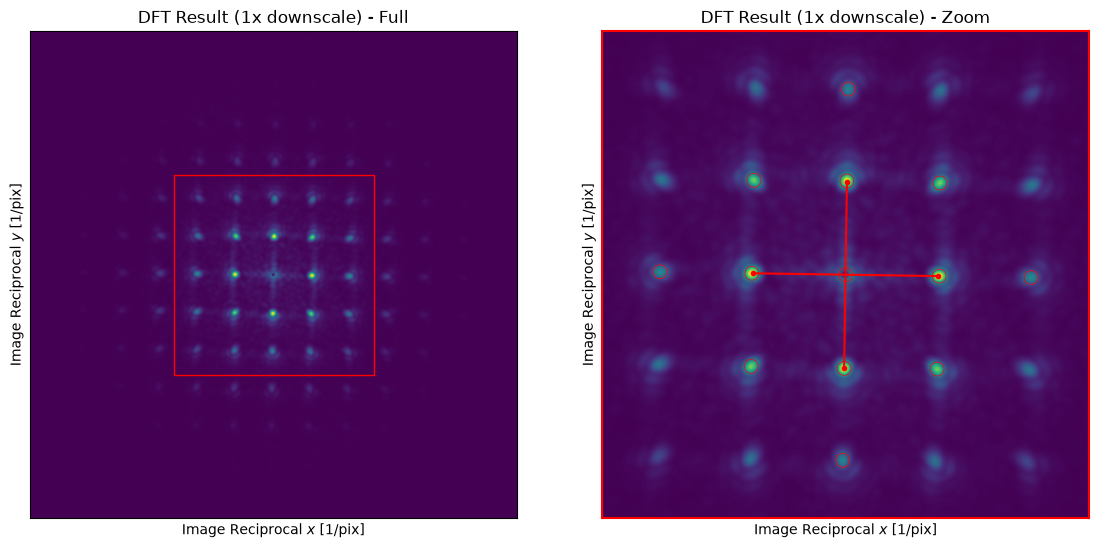

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\analysis\__init__.py:2267: UserWarning: 76.7% of the image's power outside the spot array. This might have caused the array fit to be poor.
  warnings.warn(


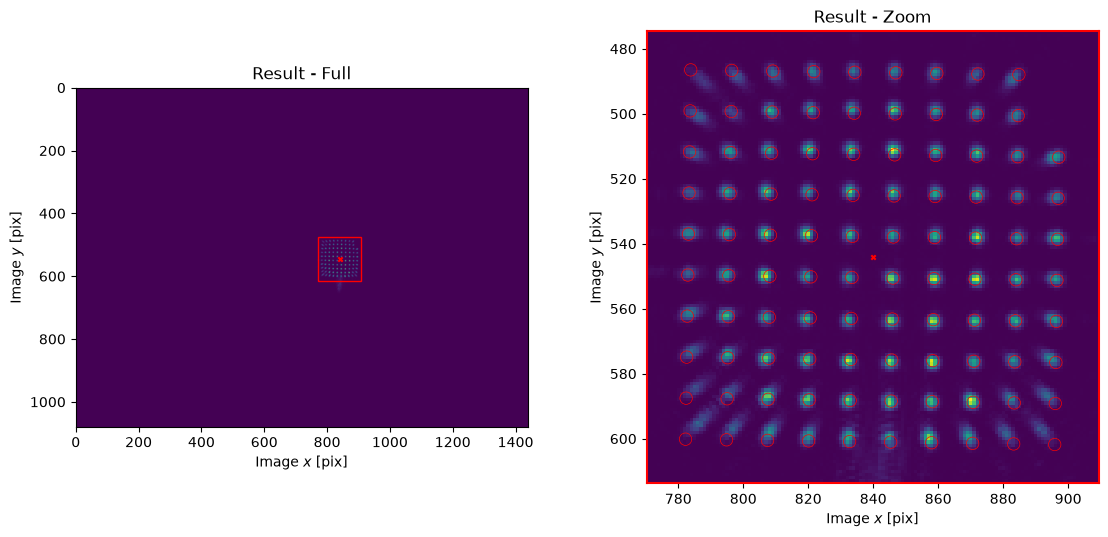

In [8]:
fs.fourier_calibrate(
    array_center=(475,0),
    array_shape=10,                 # Size of the calibration grid (Nx, Ny) [#]
    array_pitch=40,                 # Pitch of the calibration grid (x, y) [knm]
    plot=2
);

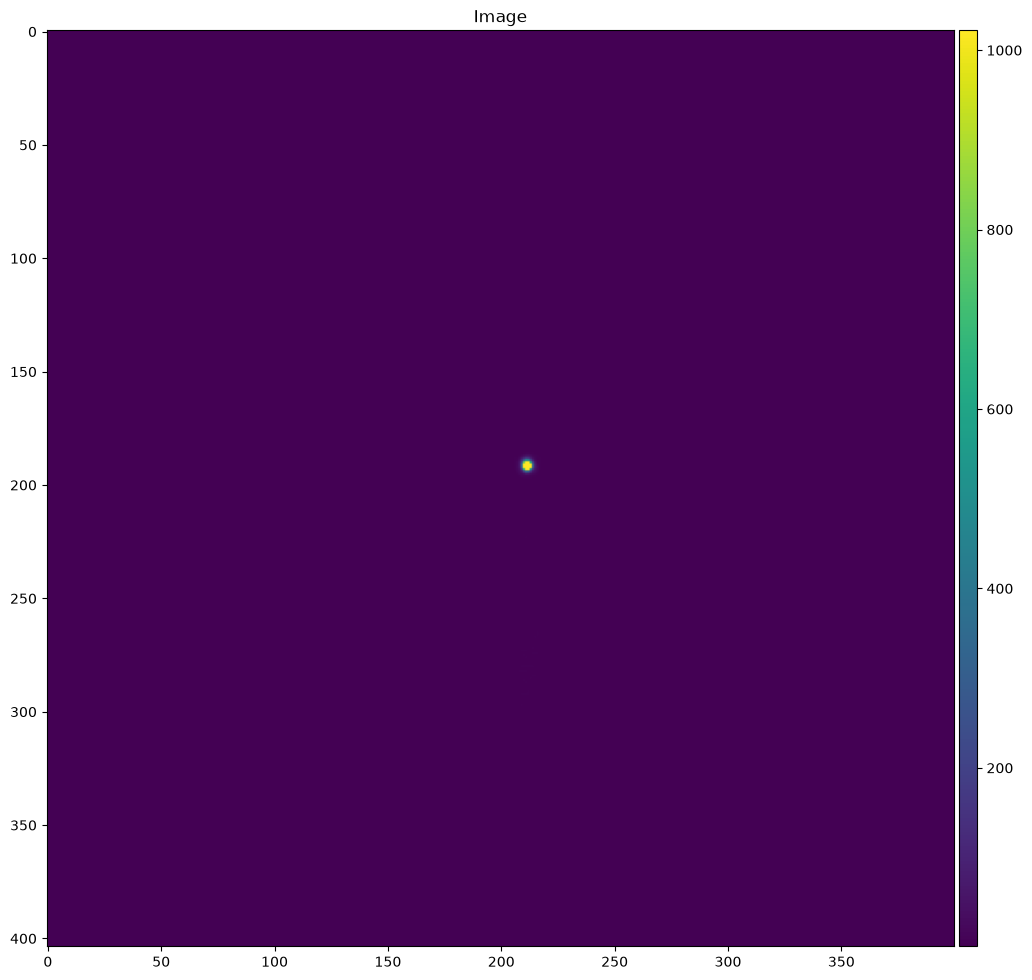

In [20]:
#fs.cam.set_woi((410, 400, 350, 400))

img = fs.cam.get_image()                                        # Grab image.

plt.figure(figsize=(12,12))
fs.cam.plot(img);

In [21]:
fs.save_calibration("fourier")

'c:\\Users\\Xander\\Documents\\Code\\slm\\38459-Meadowlark HDMI-fourier-calibration_00001.h5'

In [22]:
vector = fs.ijcam_to_kxyslm((840, 540))
print(vector)

[[2.04968322e-02]
 [1.34987253e-05]]


In [23]:
cam.set_exposure(4e-6)

4e-05

In [ ]:
blaze_phase = toolbox.phase.blaze(grid=slm, vector=vector)

fs.plot(blaze_phase, title="Blaze at pixel (840, 540)", cam_limits=.5)

img = cam.get_image()